<a href="https://colab.research.google.com/github/annaannaR/NOTEBOOKS-FROM-SCHOOL/blob/main/AMS/Machine%20Learning/PART_3/MLP3_Solutions_github.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Assignment 3.1

**Question 1**

Now try it yourself, using the same dataset, but selecting another sales category, like 'Office Supplies'.

*   Check the data for missing values, and aggregate if necessary
*   Explore the data
*   You might also want to use daily average sales
*   Train and test your model
*   Predict future values and visualize the results

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/datasets/Sample - Superstore.xlsx")
filtered_df = df.loc[df['Category'] == 'Office Supplies']
final_df = filtered_df[['Order Date','Sales']].sort_values('Order Date')
final_df.head()

,Order Date,Sales
7980,2014-01-03,16.448
740,2014-01-04,272.736
739,2014-01-04,11.784
741,2014-01-04,3.540
1759,2014-01-05,19.536


Again we see several sales on one day, which we will sum up.

In [ ]:
# Sum data by Order Date (= by day)
final_df = final_df.groupby('Order Date')['Sales'].sum().reset_index()

In [ ]:
# Check for missing values
final_df.isnull().sum()

Order Date    0
Sales         0
dtype: int64

In [ ]:
# See details of (summed) sales column
final_df.describe()

,Sales
count,1148.000000
mean,626.347589
std,995.566806
min,1.788000
25%,80.853500
50%,284.455000
75%,744.390000
max,10142.354000


In [ ]:
# Set index
final_df.set_index('Order Date', inplace=True)

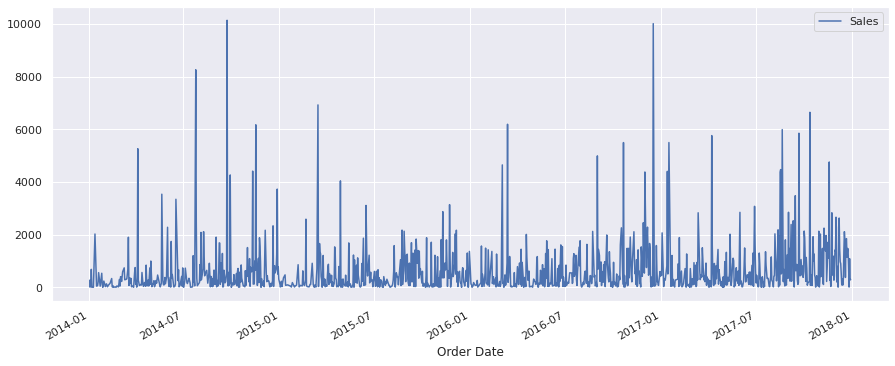

In [ ]:
# Look at data
final_df.plot(figsize=(15, 6))
plt.show()

As we also saw in the statistics of the Sales column (by using the .describe()), there are large differences in the daily sales.
There is no clear trend or seasonality. Therefore I choose to look at the average daily sales per month.

In [ ]:
new_data = final_df['Sales'].resample('MS').mean()

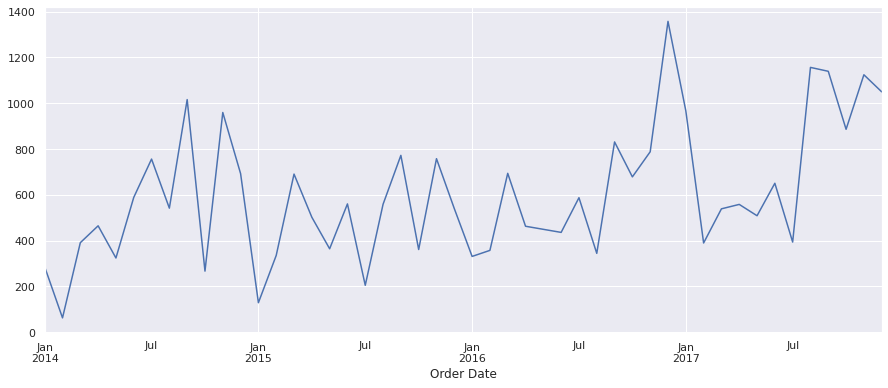

In [ ]:
# Plot result
new_data.plot(figsize=(15, 6))
plt.show()

Now it looks like there is a slight upwards trend.

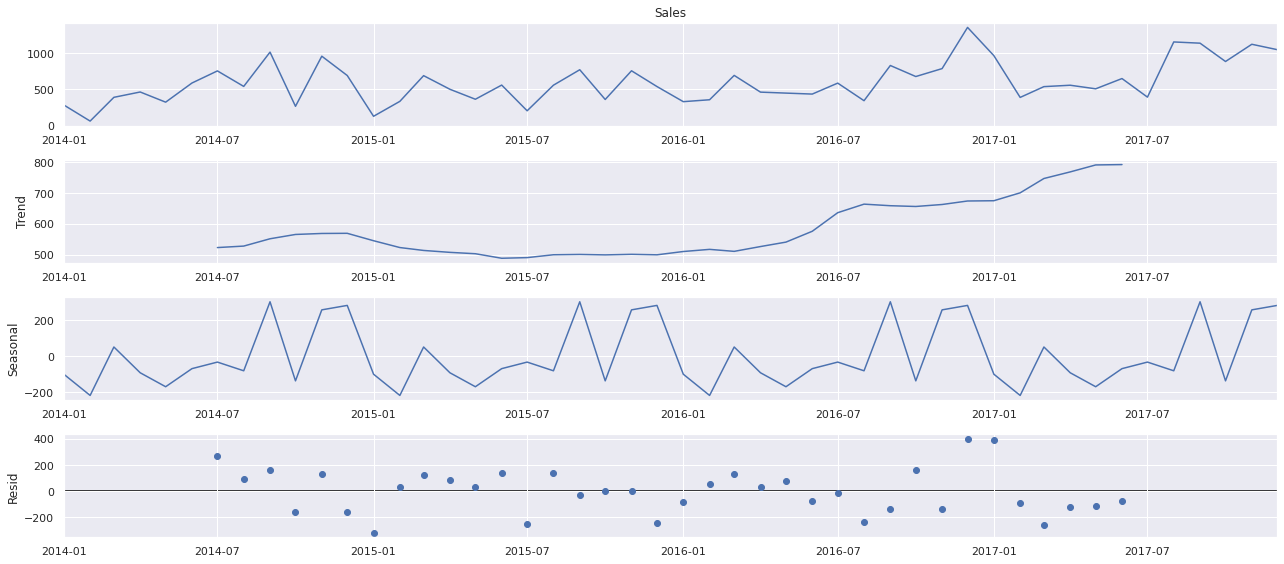

In [ ]:
from pylab import rcParams
import statsmodels.api as sm

rcParams['figure.figsize'] = 18, 8
decomposition = sm.tsa.seasonal_decompose(new_data, model='additive')
fig = decomposition.plot()
plt.show()

There is even a seasonality which I didn't see before in the regular plot. Let's train a model which uses the trend and the seasonality.

In [ ]:
# Initialize the model
mod = sm.tsa.statespace.SARIMAX(new_data,
                                order=(1, 1, 1), #(p,d,q)
                                seasonal_order=(1, 1, 0, 12)) #(p,d,q,M)

In [ ]:
# Train the model
results = mod.fit()

/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/base/tsa_model.py:132: FutureWarning: The 'freq' argument in Timestamp is deprecated and will be removed in a future version.
  date_key = Timestamp(key, freq=base_index.freq)


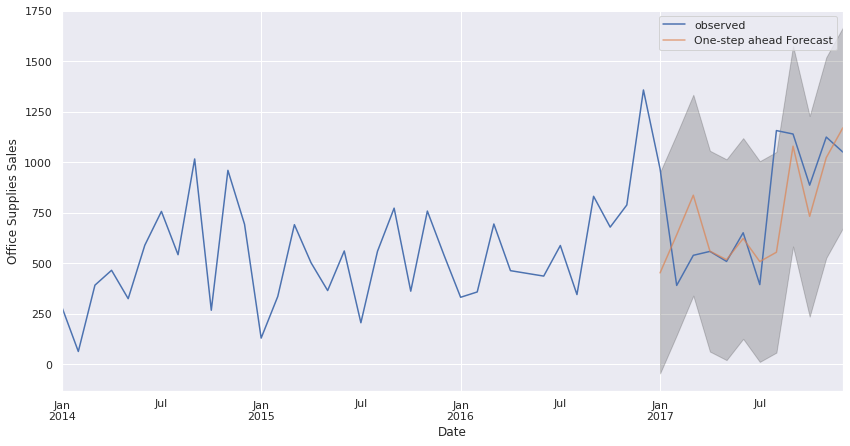

In [ ]:
# Predict from 2017
pred = results.get_prediction(start=pd.to_datetime('2017-01-01'), dynamic=False)
pred_ci = pred.conf_int() #confidence interval

# Create result-plot
ax = new_data['2014':].plot(label='observed')
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7, figsize=(14, 7))
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)
ax.set_xlabel('Date')
ax.set_ylabel('Office Supplies Sales')
plt.legend()
plt.show()

In [ ]:
# Calculate the mean absolute error from residuals
mae = np.mean(np.abs(results.resid))

# Print mean absolute error
print('MAE: %.3f' % mae)

MAE: 237.463


In [ ]:
# Make predictions for next year
pred = results.get_forecast(steps=12)
pred_ci = pred.conf_int() #confidence interval

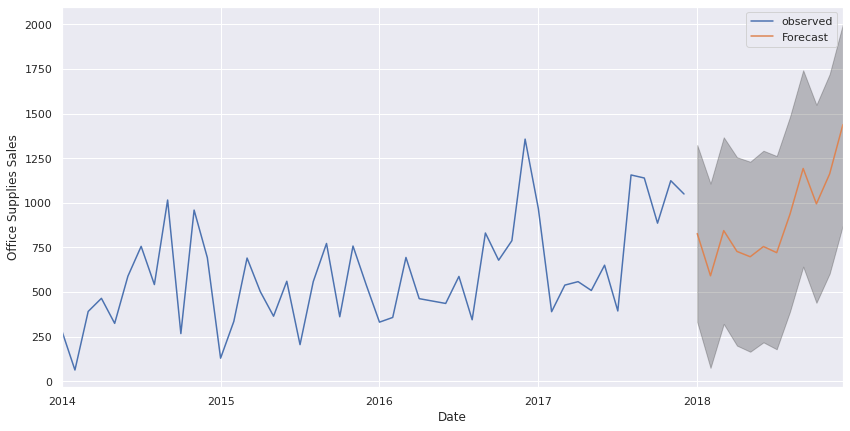

In [ ]:
# Plot the predictions
ax = new_data.plot(label='observed', figsize=(14, 7))
pred.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Date')
ax.set_ylabel('Office Supplies Sales')
plt.legend()
plt.show()

## Assignment 3.2

Now try to create clusters yourself, using the K-means algorithm. Use the following randomly created dataset:

In [ ]:
from sklearn.datasets import make_blobs
dataset, classes = make_blobs(n_samples=500, n_features=3, cluster_std=2.5, random_state=1)
data = pd.DataFrame(dataset, columns=['var1', 'var2', 'var3'])
data.head()

,var1,var2,var3
0,1.400355,0.830243,-7.861605
1,-3.883540,-3.103021,-5.082636
2,-7.535650,0.576745,-1.958125
3,2.501159,-6.482902,-12.671629
4,-3.756616,2.710163,-10.162436


**Question 1**

Explore the data, use the Elbow-method to define the optimal number of clusters, and model and visualize these clusters.

In [ ]:
data.describe()

,var1,var2,var3
count,500.000000,500.000000,500.000000
mean,-3.927463,-1.751158,-6.545196
std,3.139101,5.258594,4.174275
min,-12.013571,-13.058990,-16.812372
25%,-6.224197,-6.223963,-9.684838
50%,-3.812193,-2.265897,-7.270393
75%,-1.622326,2.620831,-3.387896
max,7.273838,10.900967,4.724322


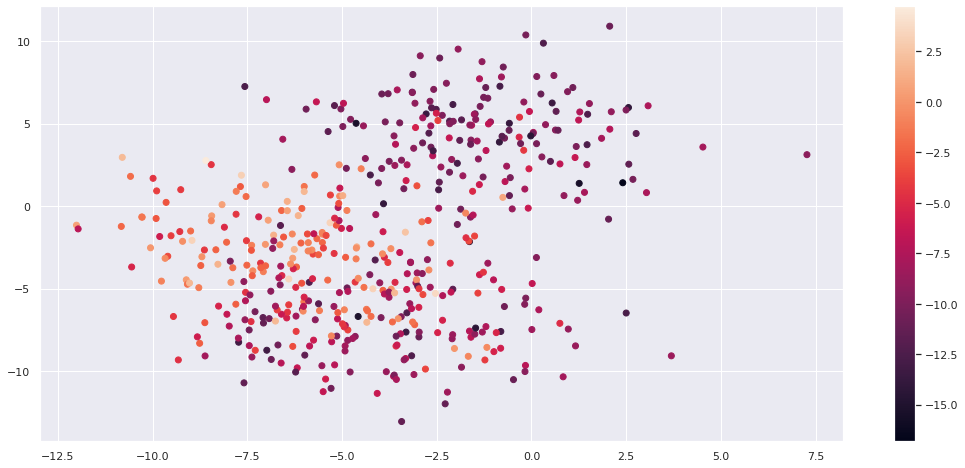

In [ ]:
# Hard to visualize 3d data, but we could use the third feature as color
# to see if we can already make something out of this
plt.scatter(data['var1'],data['var2'], c=data['var3'])
cbar= plt.colorbar()
plt.show()

Based on the collections of points, and the colours, looks like there could be 3 clusters? Let's look at the Elbow-chart.

In [ ]:
# Calculate inertia
inertia = []
for n in range(1 , 11):
    km = (KMeans(n_clusters = n, init='random', random_state= 1))
    km.fit(data)
    inertia.append(km.inertia_)

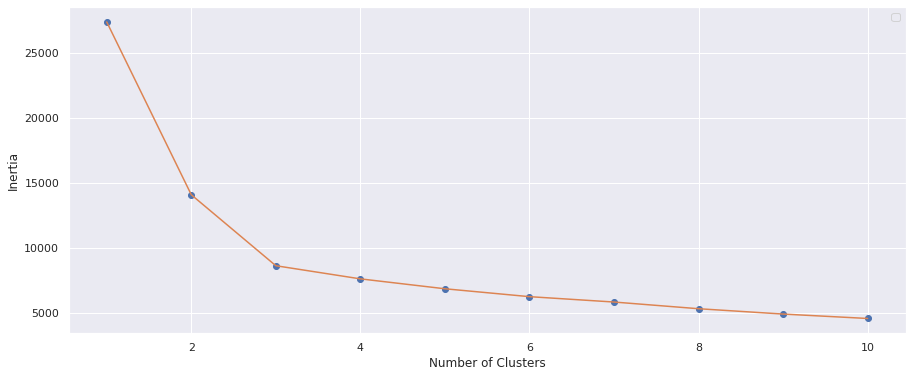

In [ ]:
# Plot the values in a matplotlib-figure
plt.figure(figsize = (15 ,6))
plt.plot(np.arange(1 , 11) , inertia, 'o')
plt.plot(np.arange(1 , 11) , inertia, '-')
plt.legend()
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

With the Elbow it indeed looks like 2 or 3 clusters would be ideal, let's go for three.

In [ ]:
# Initialize and train the final model with 3 clusters
km = (KMeans(n_clusters = 3, init='random', random_state= 1))
km.fit(data)

KMeans(init='random', n_clusters=3, random_state=1)

In [ ]:
# Check centroids
centroids = km.cluster_centers_
print("\nCentroids are:", centroids)


Centroids are: [[-4.08543293 -7.09688362 -8.30387962]
 [-6.25966093 -2.7059648  -1.79566051]
 [-1.44658789  4.23491944 -9.63949839]]


/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


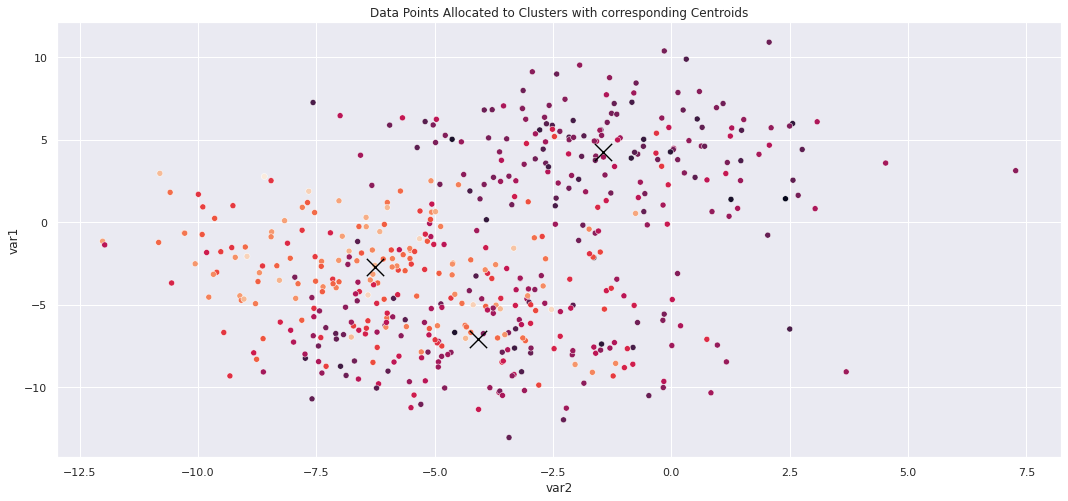

In [ ]:
# Plot clusters
sns.scatterplot(x=data['var1'],y=data['var2'], c=data['var3'])
# Plot cluster-centroids
sns.scatterplot(x = centroids[:, 0], y = centroids[:, 1], marker = "x", color = "black", s=300)
# Titles
plt.ylabel("var1")
plt.xlabel("var2")
plt.title("Data Points Allocated to Clusters with corresponding Centroids")
plt.show()

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


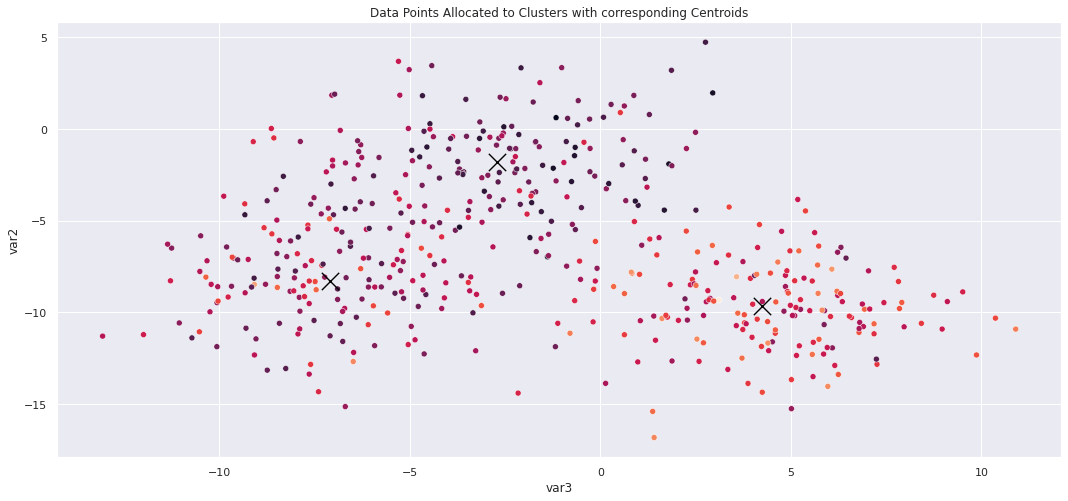

In [ ]:
# Plotting the second and third feature, with the first feature as color
# Plot clusters
sns.scatterplot(data['var2'],data['var3'], c=data['var1'])
# Plot cluster-centroids
sns.scatterplot(x = centroids[:, 1], y = centroids[:, 2], marker = "x", color = "black", s=300)
# Titles
plt.ylabel("var2")
plt.xlabel("var3")
plt.title("Data Points Allocated to Clusters with corresponding Centroids")
plt.show()